In [2]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = 'cpu'
print(f'Using device: {device}')

Using device: cpu


/data/anaconda3/envs/rosellm/lib/python3.10/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11070). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
words = open('names.txt', 'r').read().splitlines()
print(words[:8])
print(len(words))

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
32033


In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)
print(stoi)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [5]:
block_size = 3
X, Y = [], []
for w in words:
    context = [0] * block_size
    for c in w + '.':
        ix = stoi[c]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]
X, Y = torch.tensor(X, device=device), torch.tensor(Y, device=device)

In [6]:
print(X.shape, Y.shape, X.dtype, Y.dtype)
print(X[:5], Y[:5])

torch.Size([228146, 3]) torch.Size([228146]) torch.int64 torch.int64
tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1]]) tensor([ 5, 13, 13,  1,  0])


In [7]:
def build_dataset(words):
    block_size = 3
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for c in w + '.':
            ix = stoi[c]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X, Y = torch.tensor(X, device=device), torch.tensor(Y, device=device)
    return X, Y

import random 
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])
print(len(words), n1, n2, f"train: {n1}, dev: {n2-n1}, test: {len(words)-n2}")
print(Xtr.shape, Ytr.shape)
print(Xdev.shape, Ydev.shape)
print(Xte.shape, Yte.shape)


32033 25626 28829 train: 25626, dev: 3203, test: 3204
torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [8]:
emb_dim = 2
C = torch.randn((27, emb_dim), device=device)

In [9]:
emb = C[X]
print(emb.shape)

torch.Size([228146, 3, 2])


In [10]:
W1 = torch.randn((6, 100), device=device)
b1 = torch.randn(100, device=device)


In [11]:
# block_size = 2, emb_dim = 3
# block_size * emb_dim = 6
h = torch.tanh(emb.view(-1, block_size * emb_dim) @ W1 + b1)

In [12]:
h.shape

torch.Size([228146, 100])

In [13]:
W2 = torch.randn((100, 27), device=device)
b2 = torch.randn(27, device=device)
logits = h @ W2 + b2 
counts = torch.exp(logits)
probs = counts / counts.sum(dim=1, keepdim=True)

In [14]:
probs.shape, probs[0].sum(), Y.shape

(torch.Size([228146, 27]), tensor(1.0000), torch.Size([228146]))

In [15]:
X.shape, Y.shape
emb_dim = 32
input_dim = block_size * emb_dim
hidden_dim = 256
g = torch.Generator(device=device).manual_seed(2147483647)
C = torch.randn((27, emb_dim), generator=g, device=device)
W1 = torch.randn((input_dim, hidden_dim), generator=g, device=device)
b1 = torch.randn(hidden_dim, generator=g, device=device)
W2 = torch.randn((hidden_dim, 27), generator=g, device=device)
b2 = torch.randn(27, generator=g, device=device)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True
sum(p.nelement() for p in parameters)

32635

In [16]:
lre = torch.linspace(-3, 3, 1000)
lrs = 10**lre
print(lrs[:10])

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011])


In [153]:
batch_sizes = [32] # , 64, 128, 256, 512, 1024]
lris = [[] for _ in batch_sizes]
lossis = [[] for _ in batch_sizes]
stepis = [[] for _ in batch_sizes]

In [154]:
total_steps = 200000
idxs = torch.linspace(0, 1, total_steps)
# use cosine annealing
lrs = 0.1 * torch.cos(idxs * torch.pi / 2)

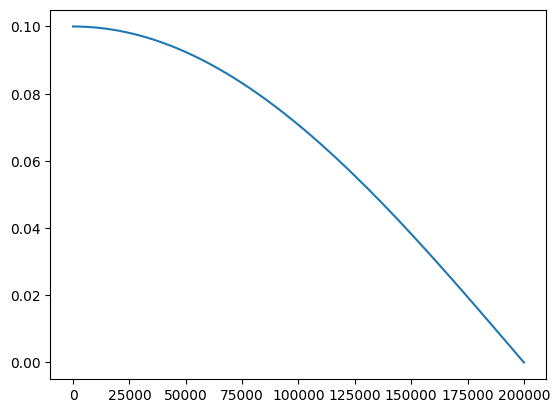

In [155]:
plt.plot([i for i in range(total_steps)], lrs.cpu().numpy())

In [ ]:
import time
lris = [[] for _ in batch_sizes]
lossis = [[] for _ in batch_sizes]
stepis = [[] for _ in batch_sizes]
for bi, batch_size in enumerate(batch_sizes):
    print(f'batch_size: {batch_size}')
    emb_dim = 16 # 10
    input_dim = block_size * emb_dim
    v1 = 5.0 / 3 / (input_dim**0.5)
    v2 = 5.0 / 3 / (hidden_dim**0.5)
    print(v1, v2)
    hidden_dim = 128 # 200
    g = torch.Generator(device=device).manual_seed(2147483647)
    C = torch.randn((27, emb_dim), generator=g, device=device)
    W1 = torch.randn((input_dim, hidden_dim), generator=g, device=device) * v1
    b1 = torch.randn(hidden_dim, generator=g, device=device) * 0
    W2 = torch.randn((hidden_dim, 27), generator=g, device=device) * v2
    b2 = torch.randn(27, generator=g, device=device) * 0
    bngain = torch.ones((1, hidden_dim), device=device)
    bnbias = torch.zeros((1, hidden_dim), device=device)
    bnmean_running = torch.zeros((1, hidden_dim), device=device)
    bnstd_running = torch.ones((1, hidden_dim), device=device)
    parameters = [C, W1, b1, W2, b2, bngain, bnbias]
    for p in parameters:
        p.requires_grad = True
    print(f'total parameters: {sum(p.nelement() for p in parameters)}')
    print_interval = total_steps // 10
    time_start = time.time()
    for i in range(total_steps):
        # mini-batch 
        ix = torch.randint(0, Xtr.shape[0], (batch_size,), device=device)
        # forward pass
        emb = C[Xtr[ix]]
        preh = emb.view(-1, input_dim) @ W1 # + b1
        bnmeani, bnstdi = preh.mean(0, keepdim=True), preh.std(0, keepdim=True)
        preh = (preh - bnmeani) / (bnstdi + 1e-10) * bngain + bnbias
        with torch.no_grad():
            bnmean_running = bnmean_running * 0.99 + bnmeani * 0.01
            bnstd_running = bnstd_running * 0.99 + bnstdi * 0.01
        h = torch.tanh(preh)
        logits = h @ W2 + b2
        # counts = torch.exp(logits)
        # probs = counts / counts.sum(dim=1, keepdim=True)
        loss = F.cross_entropy(logits, Ytr[ix])
        lr = lrs[i]
        stepis[bi].append(i)
        # lri.append(lre[i])
        lossis[bi].append(loss.log10().item())
        if i % print_interval == 0:
            elapsed = time.time() - time_start
            time_start = time.time()
            remaining_time = elapsed * (total_steps - i) / print_interval
            print(f'{i}/{total_steps}: {loss.item()}, elapsed: {elapsed:.2f}s, '
                  f'remaining: {remaining_time:.2f}s '
                  f'{remaining_time/60:.2f}m {remaining_time/3600:.2f}h, '
                  f'lr: {lr:.6f}')
        # loss = -probs[torch.arange(32), Y].log().mean()
        # backward pass
        for p in parameters:
            p.grad = None 
        loss.backward()
        # update
        for p in parameters:
            p.data += -p.grad * lr
        # break


batch_size: 32
0.2405626121623441 0.1473139127471974
total parameters: 10443
0/200000: 3.479132652282715, elapsed: 0.00s, remaining: 0.01s 0.00m 0.00h, lr: 0.100000
20000/200000: 2.3492794036865234, elapsed: 20.77s, remaining: 186.95s 3.12m 0.05h, lr: 0.098769
40000/200000: 2.271176338195801, elapsed: 21.37s, remaining: 170.94s 2.85m 0.05h, lr: 0.095106
60000/200000: 2.471683979034424, elapsed: 21.17s, remaining: 148.22s 2.47m 0.04h, lr: 0.089101
80000/200000: 2.138132333755493, elapsed: 20.84s, remaining: 125.04s 2.08m 0.03h, lr: 0.080902
100000/200000: 2.2798116207122803, elapsed: 20.81s, remaining: 104.03s 1.73m 0.03h, lr: 0.070710
120000/200000: 2.165221691131592, elapsed: 20.90s, remaining: 83.60s 1.39m 0.02h, lr: 0.058778
140000/200000: 2.2466936111450195, elapsed: 20.70s, remaining: 62.10s 1.04m 0.02h, lr: 0.045399
160000/200000: 1.9152097702026367, elapsed: 21.88s, remaining: 43.76s 0.73m 0.01h, lr: 0.030901
180000/200000: 2.185788631439209, elapsed: 21.11s, remaining: 21.11s 0

In [200]:
print(b1.grad.max(), b1.grad.min())
print(b2.grad.max(), b2.grad.min())

tensor(4.8894e-09) tensor(-5.1223e-09)
tensor(0.0399) tensor(-0.0578)


In [187]:
preh.mean(0, keepdim=True).shape

torch.Size([1, 128])

In [188]:
print(f'total parameters: {sum(p.nelement() for p in parameters)}')

total parameters: 10443


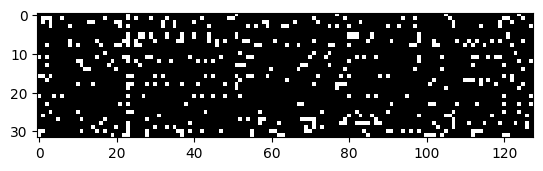

In [189]:
plt.imshow(h.abs() > 0.99, cmap='gray')

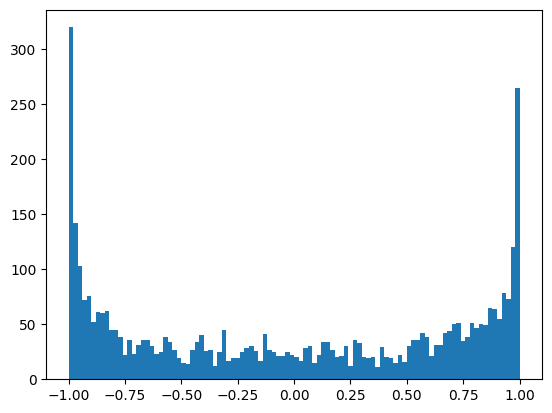

In [190]:
plt.hist(h.view(-1).tolist(), bins=100);

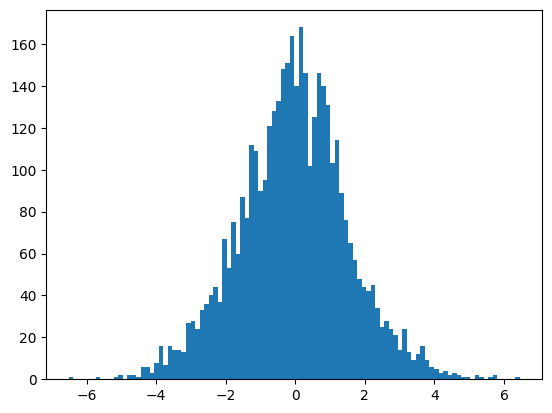

In [191]:
plt.hist(preh.view(-1).tolist(), bins=100);

In [192]:
# plt.plot(lri, lossi)

In [193]:
-torch.log(torch.tensor(1/27.0))

tensor(3.2958)

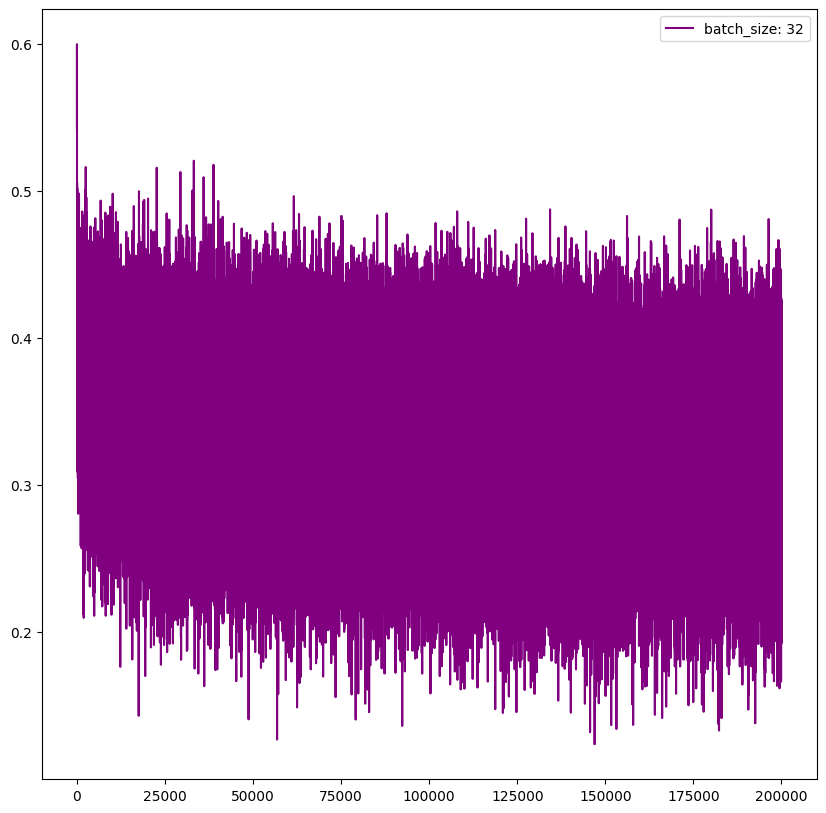

In [194]:
plt.figure(figsize=(10,10))
colors = ['purple', 'red', 'green', 'yellow', 'blue', 'orange']
# for bi, (bs, losses, c) in enumerate(zip(batch_sizes[0::5], lossis[0::5], colors)):
    # plt.plot(stepis[bi], losses, c, label=f'batch_size: {bs}')
plt.plot(stepis[0], lossis[0], 'purple', label=f'batch_size: {batch_sizes[0]}')
plt.legend()
plt.show()


In [195]:
with torch.no_grad():
    emb = C[Xtr]
    preh = emb.view(-1, input_dim) @ W1 + b1
    bnmean = preh.mean(0, keepdim=True)
    bnstd = preh.std(0, keepdim=True)

In [198]:
(bnmean - bnmean_running).abs().max(), (bnstd - bnstd_running).abs().max()

(tensor(0.0919), tensor(0.0793))

In [196]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'dev': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x]
    preh = emb.view(-1, input_dim) @ W1 + b1
    # preh = (preh - preh.mean(0, keepdim=True)) / (preh.std(0, keepdim=True) + 1e-10) * bngain + bnbias
    # preh = (preh - bnmean) / (bnstd + 1e-10) * bngain + bnbias
    preh = (preh - bnmean_running) / (bnstd_running + 1e-10) * bngain + bnbias
    h = torch.tanh(preh)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(f'{split} loss: {loss.item()}')
    return loss.item()
split_loss('train')
split_loss('dev')
split_loss('test')


train loss: 2.0607240200042725
dev loss: 2.108802318572998
test loss: 2.10155987739563


2.10155987739563

In [197]:
g = torch.Generator().manual_seed(2147483647+10)
for i in range(20):
    out = []
    context = [0] * block_size 
    while True:
        emb = C[torch.tensor([context])]
        preh = emb.view(-1, input_dim) @ W1 + b1
        # preh = (preh - bnmean) / (bnstd + 1e-10) * bngain + bnbias
        preh = (preh - bnmean_running) / (bnstd_running + 1e-10) * bngain + bnbias
        h = torch.tanh(preh)
        logits = h @ W2 + b2 
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        context = context[1:] + [ix]
        if ix == 0:
            break
    print(''.join(out))

mora.
kayanniellend.
ryla.
remmadiendra.
grace.
korelin.
shi.
jenleigh.
estanar.
kayzioh.
kamin.
shub.
rishimiel.
kindreelynn.
novana.
ubzer.
dariyah.
fael.
yuva.
myston.


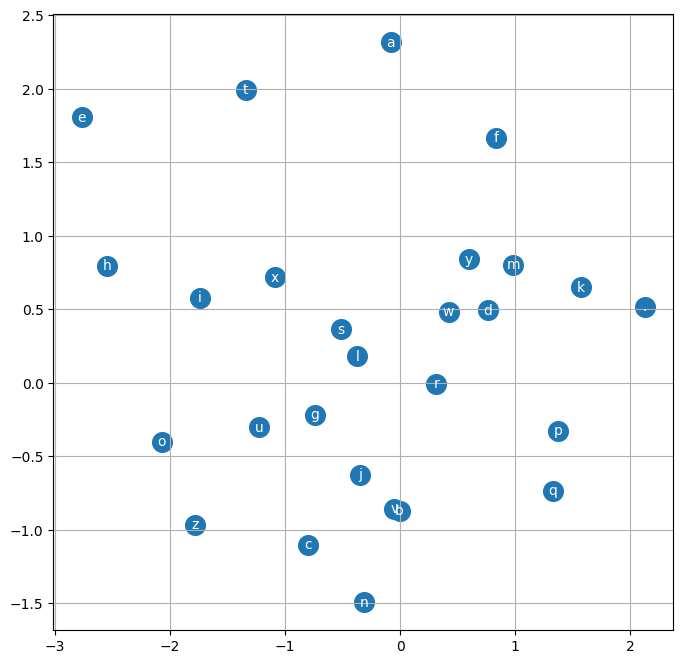

In [196]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
plt.grid(True)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha='center', va='center', color='white')

In [386]:
# summary 
g = torch.Generator().manual_seed(2147483647)
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in ** 0.5
        self.bias = torch.zeros((1, fan_out), generator=g) if bias else None
    def __call__(self, x):
        self.out = x @ self.weight 
        if self.bias is not None:
            self.out += self.bias 
        return self.out 
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum 
        self.training = True
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    def __call__(self, x):
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True)
        else:
            xmean = self.running_mean 
            xvar = self.running_var 
        xhat = (x - xmean) / (xvar + self.eps) ** 0.5
        self.out = self.gamma * xhat + self.beta 
        if self.training:
            with torch.no_grad():
                self.running_mean = self.running_mean * self.momentum + xmean * (1 - self.momentum)
                self.running_var = self.running_var * self.momentum + xvar * (1 - self.momentum)
        return self.out 
    def parameters(self):
        return [self.gamma, self.beta]
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out 
    def parameters(self):
        return []
n_embed = 8
n_hidden = 64
vocab_size = 27 
C = torch.randn((vocab_size, n_embed), generator=g)
layers = [
    Linear(n_embed * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size, bias=False), BatchNorm1d(vocab_size),
]
with torch.no_grad():
    # layers[-1].weight *= 0.1 
    layers[-1].gamma *= 0.1 
    for l in layers[:-1]:
        if isinstance(l, Linear):
            l.weight *= 5 / 3
        
parameters = [C] + [p for l in layers for p in l.parameters()]
print(f'total parameters: {sum(p.nelement() for p in parameters)}')
for p in parameters:
    p.requires_grad = True

total parameters: 24782


In [387]:
max_steps = 200000
batch_size = 32
print_interval = max_steps // 10
time_start = time.time()
lrs = 0.1 * torch.cos(torch.linspace(0, 1, max_steps) * torch.pi / 2)
lossi = []
ud = []
for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), device=device)
    Xb, Yb = Xtr[ix], Ytr[ix]
    emb = C[Xb]
    x = emb.view(-1, block_size * n_embed)
    for l in layers:
        x = l(x)
    loss = F.cross_entropy(x, Yb)
    lossi.append(loss.item())
    for l in layers:
        l.out.retain_grad()
    for p in parameters:
        p.grad = None 
    loss.backward()
    lr = lrs[i]
    for p in parameters:
        p.data += -p.grad * lr
    if i % print_interval == 0:
        elapsed = time.time() - time_start
        time_start = time.time()
        remaining_time = elapsed * (max_steps - i) / print_interval
        print(f'{i}/{max_steps}: {loss.item()}, elapsed: {elapsed:.2f}s, '
              f'remaining: {remaining_time:.2f}s {remaining_time/60:.2f}m {remaining_time/3600:.2f}h, '
              f'lr: {lr:.6f}')
    with torch.no_grad():
        ud.append([(lr * p.grad.std() / p.data.std()).log10().item() for p in parameters])
    # if i == 1000:
    #     break


0/200000: 3.31503963470459, elapsed: 0.01s, remaining: 0.06s 0.00m 0.00h, lr: 0.100000
20000/200000: 2.830043315887451, elapsed: 93.61s, remaining: 842.49s 14.04m 0.23h, lr: 0.098769
40000/200000: 2.339179754257202, elapsed: 94.11s, remaining: 752.90s 12.55m 0.21h, lr: 0.095106
60000/200000: 1.8948808908462524, elapsed: 97.59s, remaining: 683.11s 11.39m 0.19h, lr: 0.089101
80000/200000: 2.207094192504883, elapsed: 95.19s, remaining: 571.15s 9.52m 0.16h, lr: 0.080902
100000/200000: 2.285919189453125, elapsed: 94.96s, remaining: 474.82s 7.91m 0.13h, lr: 0.070710
120000/200000: 2.1802234649658203, elapsed: 94.02s, remaining: 376.06s 6.27m 0.10h, lr: 0.058778
140000/200000: 2.225337266921997, elapsed: 95.24s, remaining: 285.71s 4.76m 0.08h, lr: 0.045399
160000/200000: 2.1834664344787598, elapsed: 95.19s, remaining: 190.37s 3.17m 0.05h, lr: 0.030901
180000/200000: 2.066497802734375, elapsed: 94.70s, remaining: 94.70s 1.58m 0.03h, lr: 0.015643


layer 2 Tanh, mean: 0.04, std: 0.71, saturated: 12.99%
torch.Size([101]) torch.Size([100])


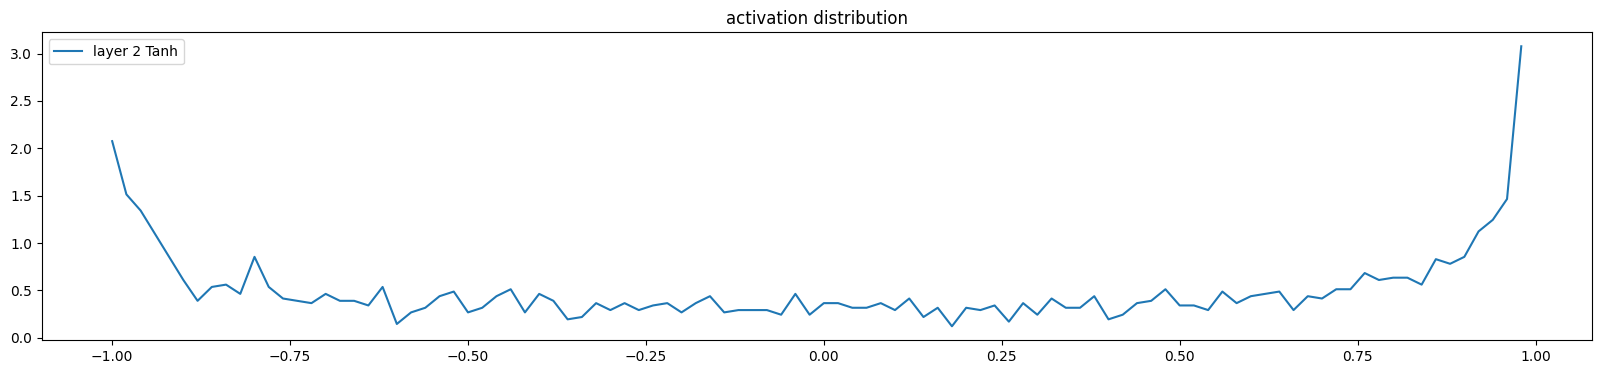

In [388]:
plt.figure(figsize=(20,4))
legends = []
for i, l in enumerate(layers[:3]):
    if isinstance(l, Tanh):
        t = l.out 
        print(f'layer {i} {l.__class__.__name__}, mean: {t.mean():.2f}, std: {t.std():.2f}, saturated: {(t.abs() > 0.97).sum() / t.numel():.2%}')
        hy, hx = torch.histogram(t, density=True)
        print(hx.shape, hy.shape)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} {l.__class__.__name__}')
plt.legend(legends)
plt.title('activation distribution')
plt.show()


In [389]:
print(hy.sum(), hx.shape, hx[0], hx[1])

tensor(50.0011, grad_fn=<SumBackward0>) torch.Size([101]) tensor(-1.0000, grad_fn=<SelectBackward0>) tensor(-0.9800, grad_fn=<SelectBackward0>)


layer 2 Tanh, mean: -0.00, std: 0.01, saturated: 0.00%
torch.Size([101]) torch.Size([100])
layer 5 Tanh, mean: -0.00, std: 0.01, saturated: 0.00%
torch.Size([101]) torch.Size([100])
layer 8 Tanh, mean: -0.00, std: 0.01, saturated: 0.00%
torch.Size([101]) torch.Size([100])
layer 11 Tanh, mean: -0.00, std: 0.01, saturated: 0.00%
torch.Size([101]) torch.Size([100])
layer 14 Tanh, mean: -0.00, std: 0.00, saturated: 0.00%
torch.Size([101]) torch.Size([100])
layer 17 Tanh, mean: -0.00, std: 0.00, saturated: 0.00%
torch.Size([101]) torch.Size([100])


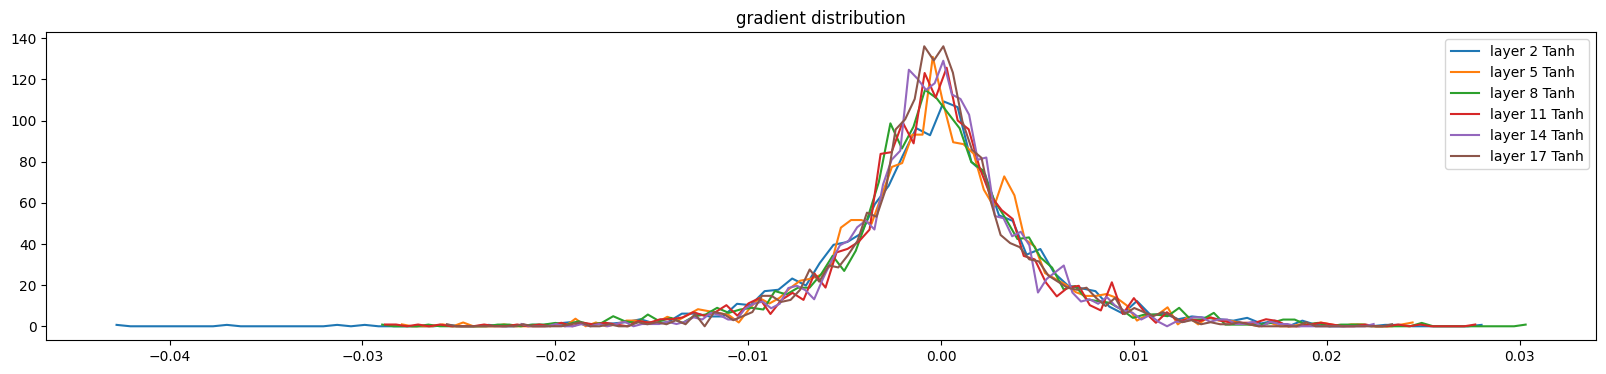

In [390]:
plt.figure(figsize=(20,4))
legends = []
for i, l in enumerate(layers[:-1]):
    if isinstance(l, Tanh):
        t = l.out.grad
        print(f'layer {i} {l.__class__.__name__}, mean: {t.mean():.2f}, std: {t.std():.2f}, saturated: {(t.abs() > 0.97).sum() / t.numel():.2%}')
        hy, hx = torch.histogram(t, density=True)
        print(hx.shape, hy.shape)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} {l.__class__.__name__}')
plt.legend(legends)
plt.title('gradient distribution')
plt.show()


weight shape: torch.Size([27, 8]), grad mean: 2.59e-10, grad std: 1.88e-02, grad std / data std: 1.64%
weight shape: torch.Size([24, 64]), grad mean: -2.64e-04, grad std: 1.10e-02, grad std / data std: 2.25%
weight shape: torch.Size([64, 64]), grad mean: -8.95e-05, grad std: 7.81e-03, grad std / data std: 2.42%
weight shape: torch.Size([64, 64]), grad mean: 1.64e-04, grad std: 8.66e-03, grad std / data std: 2.73%
weight shape: torch.Size([64, 64]), grad mean: -2.06e-05, grad std: 8.05e-03, grad std / data std: 2.58%
weight shape: torch.Size([64, 64]), grad mean: -6.79e-05, grad std: 7.19e-03, grad std / data std: 2.36%
weight shape: torch.Size([64, 64]), grad mean: -2.05e-04, grad std: 6.74e-03, grad std / data std: 2.28%
weight shape: torch.Size([64, 27]), grad mean: -8.44e-05, grad std: 8.31e-03, grad std / data std: 2.14%


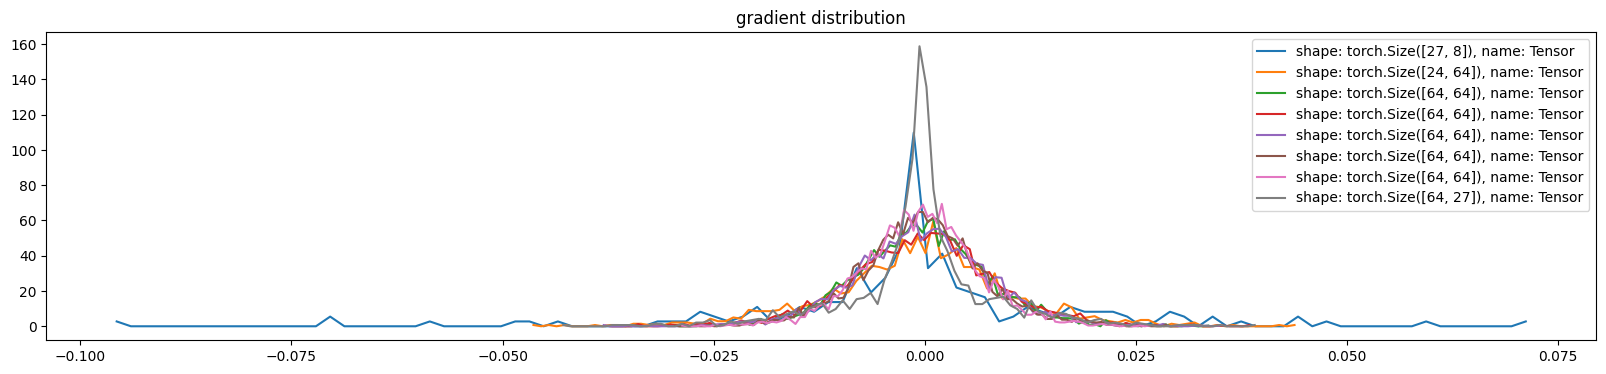

In [391]:
plt.figure(figsize=(20,4))
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print(f'weight shape: {p.shape}, grad mean: {t.mean():.2e}, grad std: {t.std():.2e}, grad std / data std: {t.std() / p.std():.2%}')
        hy, hx = torch.histogram(t, density=True)
        # print(hx.shape, hy.shape)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'shape: {p.shape}, name: {p.__class__.__name__}')
plt.legend(legends)
plt.title('gradient distribution')
plt.show()


In [392]:
ud

[[-3.682591199874878,
  -3.1249966621398926,
  -6.445653980335919e-06,
  -2.5885968923944347e-08,
  -2.9082467555999756,
  1.501383621871355e-06,
  0.0,
  -2.965142250061035,
  3.72756335309532e-06,
  -5.177194140060237e-08,
  -3.045078992843628,
  9.318938509750296e-07,
  0.0,
  -3.1210362911224365,
  1.3149872756912373e-05,
  0.0,
  -3.0994961261749268,
  -1.242528242073604e-06,
  -2.5885968923944347e-08,
  -2.984320640563965,
  1.0354386148492267e-07,
  0.0],
 [-3.7643537521362305,
  -3.2378649711608887,
  -0.23814059793949127,
  -0.2462715357542038,
  -3.030673027038574,
  -0.20056700706481934,
  -0.1599055528640747,
  -3.081071138381958,
  -0.1615157574415207,
  -0.228581041097641,
  -3.1264736652374268,
  -0.23020486533641815,
  -0.22943662106990814,
  -3.169971466064453,
  -0.21418707072734833,
  -0.22079503536224365,
  -3.2082371711730957,
  -0.230448380112648,
  -0.1475515216588974,
  -3.061776638031006,
  0.048759184777736664,
  -0.18250350654125214],
 [-3.6615264415740967,
 

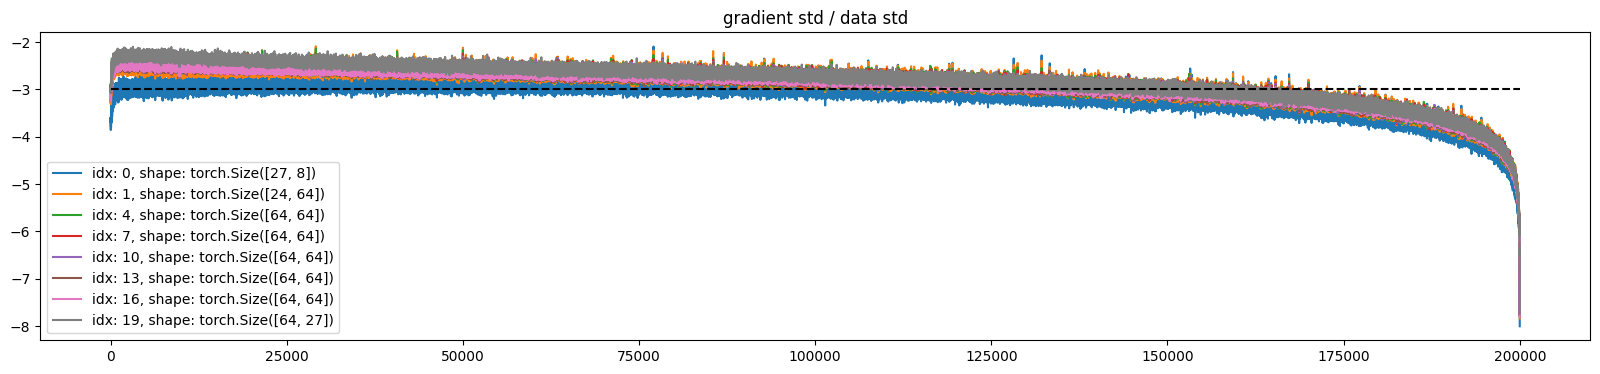

In [393]:
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append(f'idx: {i}, shape: {p.shape}')
plt.plot([0, len(ud)], [-3, -3], 'k--')  # should be around 1e-3
plt.legend(legends)
plt.title('gradient std / data std')
plt.show()


In [394]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'dev': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x]
    x = emb.view(-1, block_size * n_embed)
    for l in layers:
        if isinstance(l, BatchNorm1d):
            l.training = False
        x = l(x)
    loss = F.cross_entropy(x, y)
    print(f'{split} loss: {loss.item()}')
    return loss.item()
split_loss('train')
split_loss('dev')
split_loss('test')


train loss: 2.110469341278076
dev loss: 2.158036708831787
test loss: 2.163099765777588


2.163099765777588

$z(x) = \frac{1}{1+e^{W^Tx}}$